<a href="https://colab.research.google.com/github/diegoVasquez600/Statistics_for_Analytics/blob/main/ANOVA_est_IUPB_Diego_Rios_Vasquez_Juan_David_Perez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

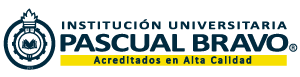

# **ANOVA**

## Entregable 5: ANOVA
## Estadistica para Analitica
## Profesora: Ingry Natalia Gómez Miranda
## Estudiantes:
  #### - Diego Alejanro Rios Vasquez
  #### - Juan David Perez

# **1. Presentación de los datos**

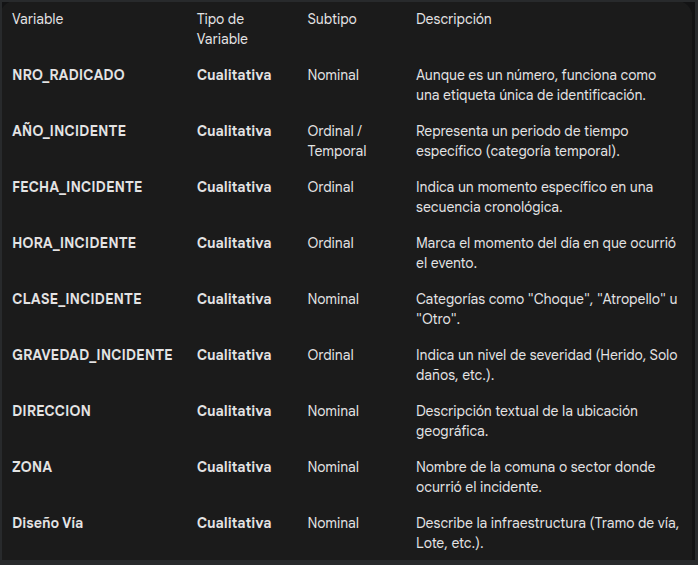

# **2. Cargar el conjunto de datos**

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
#Cargando archivo desde el directorio de trabajo
from google.colab import files
import pandas as pd

# Cargar un archivo desde tu dispositivo local
Archivo = files.upload()

# Obtener la ruta del archivo cargado
Ruta = list(Archivo.keys())[0]

# Leer el archivo con pandas
try:
  datos = pd.read_csv(Ruta,sep=',', encoding='latin1', low_memory=False)
except UnicodeDecodeError:
  datos = pd.read_csv(Ruta,sep=',', encoding='utf-8', low_memory=False)

# Mostrar los 10 primeros registros del DataFrame
print()
datos.head(10)

Saving incidentes_viales_motos.csv to incidentes_viales_motos (3).csv



,NRO_RADICADO,AÃO_INCIDENTE,FECHA_INCIDENTE,HORA_INCIDENTE,CLASE_INCIDENTE,GRAVEDAD_INCIDENTE,DIRECCION,ZONA,DiseÃ±o VÃ­a
0,1471551,2015,10/01/2015,23:23:00,Choque,HERIDO,Carrera 80 Con Calle 44 B,COMUNA 12,Tramo de via
1,1471559,2015,10/01/2015,20:00:00,Atropello,HERIDO,Carrera 111 Con Calle 34 CC,COMUNA 13,Tramo de via
2,1471643,2015,10/01/2015,17:40:00,Choque,SOLO DA\xD1OS,Carrera 49 Con Calle 79,COMUNA 4,Tramo de via\r
3,1471663,2015,10/01/2015,20:20:00,Choque,SOLO DA\xD1OS,Calle 30 Con Carrera 79 A,COMUNA 16,Tramo de via\r
4,1471664,2015,10/01/2015,14:50:00,Choque,SOLO DA\xD1OS,Calle 44 A Con Carrera 73,COMUNA 11,Ciclo Ruta\r
5,1471681,2015,10/01/2015,19:00:00,Choque,SOLO DA\xD1OS,Carrera 65 Con Calle 112,COMUNA 5,Tramo de via\r
6,1471699,2015,10/01/2015,21:20:00,Choque,SOLO DA\xD1OS,Calle 43 Con Carrera 97,Jurisdicci\xF3n,Interseccion\r
7,1471700,2015,10/01/2015,15:20:00,Choque,SOLO DA\xD1OS,Carrera 999 Con Calle 999,Jurisdicci\xF3n,Tramo de via\r
8,1471702,2015,10/01/2015,11:10:00,Choque,SOLO DA\xD1OS,Calle 23 Con Carrera 43 A,COMUNA 14,Tramo de via\r
9,1471711,2015,10/01/2015,23:45:00,Choque,SOLO DA\xD1OS,Carrera 83 Con Calle 101 B,Jurisdicci\xF3n,Tramo de via\r


In [41]:
import pandas as pd
import numpy as np
from scipy.stats import kstest, norm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.api as sm
import scipy.stats as st
from scipy import stats
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.api import het_breuschpagan
from statsmodels.graphics.gofplots import qqplot
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy.stats import levene

In [42]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223439 entries, 0 to 223438
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   NRO_RADICADO        223439 non-null  int64 
 1   AÃO_INCIDENTE      223439 non-null  int64 
 2   FECHA_INCIDENTE     223439 non-null  object
 3   HORA_INCIDENTE      223439 non-null  object
 4   CLASE_INCIDENTE     223435 non-null  object
 5   GRAVEDAD_INCIDENTE  223439 non-null  object
 6   DIRECCION           223436 non-null  object
 7   ZONA                223439 non-null  object
 8   DiseÃ±o VÃ­a        223439 non-null  object
dtypes: int64(2), object(7)
memory usage: 15.3+ MB


### Preparacion y Transformacion de Datos

In [43]:
# Limpieza básica: quitar valores nulos en fecha o zona
datos = datos.dropna(subset=['FECHA_INCIDENTE', 'ZONA'])
datos['ZONA'] = datos['ZONA'].str.strip()

# Filtrar las zonas principales para evitar ruido ("Sin Inf" o zonas con muy pocos datos)
zonas_validas = datos['ZONA'].value_counts()[datos['ZONA'].value_counts() > 100].index
datos = datos[datos['ZONA'].isin(zonas_validas)]

# Convertir fecha y eliminar errores
datos['FECHA_INCIDENTE'] = pd.to_datetime(datos['FECHA_INCIDENTE'], dayfirst=True, errors='coerce')
datos = datos.dropna(subset=['FECHA_INCIDENTE'])
# Para aplicar ANOVA, agrupamos para contar accidentes por Zona y Mes
datos['AÑO_MES'] = datos['FECHA_INCIDENTE'].dt.to_period('M')
df_anova = datos.groupby(['ZONA', 'AÑO_MES']).size().reset_index(name='CANTIDAD_ACCIDENTES')
df_anova['AÑO_MES'] = df_anova['AÑO_MES'].astype(str)

print("Datos agrupados listos para el análisis:")
df_anova.head(10)

Datos agrupados listos para el análisis:


,ZONA,AÑO_MES,CANTIDAD_ACCIDENTES
0,CARRETERA LAS PALMAS Jurisdicci\xF3n,2015-01,1
1,CARRETERA LAS PALMAS Jurisdicci\xF3n,2015-06,1
2,CARRETERA LAS PALMAS Jurisdicci\xF3n,2015-08,2
3,CARRETERA LAS PALMAS Jurisdicci\xF3n,2015-11,2
4,CARRETERA LAS PALMAS Jurisdicci\xF3n,2015-12,1
5,CARRETERA LAS PALMAS Jurisdicci\xF3n,2016-10,1
6,CARRETERA LAS PALMAS Jurisdicci\xF3n,2017-01,1
7,CARRETERA LAS PALMAS Jurisdicci\xF3n,2017-06,2
8,CARRETERA LAS PALMAS Jurisdicci\xF3n,2017-07,2
9,CARRETERA LAS PALMAS Jurisdicci\xF3n,2017-08,3


In [44]:
#El resumen estadístico de nuestro dataset total.
datos.describe()

,NRO_RADICADO,AÃO_INCIDENTE,FECHA_INCIDENTE
count,1.702360e+05,170236.000000,170236
mean,1.616572e+06,2017.703658,2018-03-13 00:45:58.937005056
min,1.470349e+06,2015.000000,2015-01-01 00:00:00
25%,1.543249e+06,2016.000000,2016-07-19 00:00:00
50%,1.615742e+06,2018.000000,2018-02-07 00:00:00
75%,1.691414e+06,2019.000000,2019-10-15 00:00:00
max,1.760725e+06,2021.000000,2021-08-31 00:00:00
std,8.432625e+04,1.913942,NaN


### Analisis Exploratorio


/tmp/ipykernel_453/1359148611.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ZONA', y='CANTIDAD_ACCIDENTES', data=df_anova, palette='Set2')


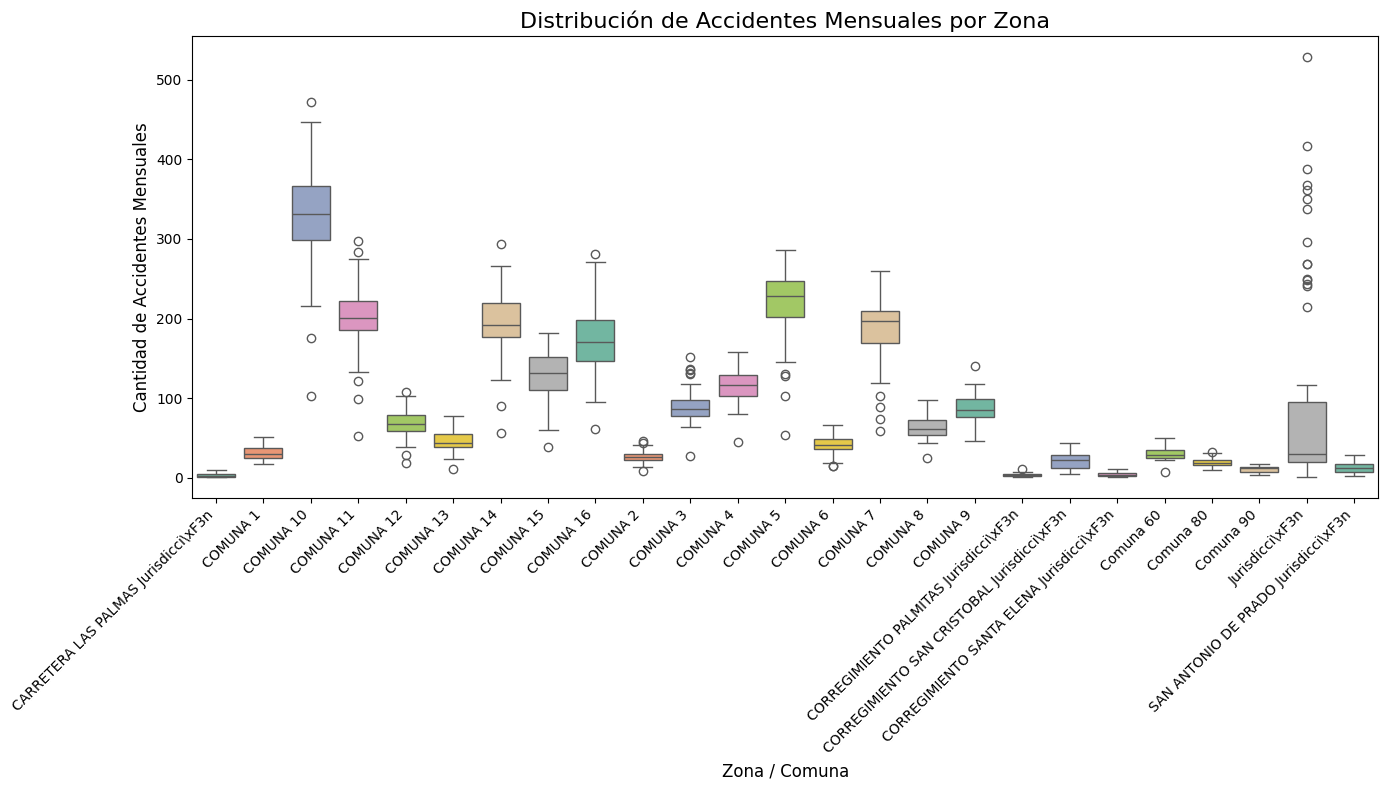

In [45]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='ZONA', y='CANTIDAD_ACCIDENTES', data=df_anova, palette='Set2')
plt.title('Distribución de Accidentes Mensuales por Zona', fontsize=16)
plt.xlabel('Zona / Comuna', fontsize=12)
plt.ylabel('Cantidad de Accidentes Mensuales', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **3. Prueba de normalidad**

**Planteamos las hipótesis**

 $$ H_{0}:\text{La cantidad de accidentes proviene de una distribución Normal}$$
 $$ H_{1}:\text{La cantidad de accidentes NO proviene de una distribución Normal}$$

 Si el valor p es menor a 0.05 se debe rechazar H0


In [46]:
media_CANTIDAD = df_anova['CANTIDAD_ACCIDENTES'].mean()
varianza_CANTIDAD = df_anova['CANTIDAD_ACCIDENTES'].var()
desvest_CANTIDAD = np.sqrt(varianza_CANTIDAD)

# Test de Kolmogorov-Smirnov contra una N(mu, sigma)
ks_statistic, p_value = stats.kstest(df_anova['CANTIDAD_ACCIDENTES'], 'norm', args=(media_CANTIDAD, desvest_CANTIDAD))

print(f"KS statistic: {ks_statistic:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print(f"Como {p_value:.4f} < 0.05 se debe rechazar H0, entonces la variable NO proviene de una distribución Normal")
    print("\nEn este caso debemos buscar una transformación de potencia que normalice la variable que no es normal. Primero ensayamos con logaritmo natural (Ln).")

    # Obtenemos el logaritmo natural
    L_CANTIDAD = np.log(df_anova['CANTIDAD_ACCIDENTES'])

    # Realizamos de nuevo el test de normalidad
    media_L = L_CANTIDAD.mean()
    varianza_L = L_CANTIDAD.var()
    desvest_L = np.sqrt(varianza_L)

    # Test de Kolmogorov-Smirnov contra una N(mu, sigma)
    ks_statistic_L, p_value_L = stats.kstest(L_CANTIDAD, 'norm', args=(media_L, desvest_L))

    print(f"Transformación Ln - KS statistic: {ks_statistic_L:.4f}, p-value: {p_value_L:.4f}")

    if p_value_L < 0.05:
        print(f"Como {p_value_L:.4f} < 0.05, se debe rechazar H0, lo que indica que NO existe NORMALIDAD en la variable transformada")
    else:
        print(f"Como {p_value_L:.4f} >= 0.05, no se rechaza H0, existe NORMALIDAD en la variable transformada")

    # Se adiciona la nueva columa al dataframe
    df_anova['L_CANTIDAD_ACCIDENTES'] = L_CANTIDAD
else:
    print(f"Como {p_value:.4f} >= 0.05, no se rechaza H0, existe NORMALIDAD en la variable")


KS statistic: 0.1387, p-value: 0.0000
Como 0.0000 < 0.05 se debe rechazar H0, entonces la variable NO proviene de una distribución Normal

En este caso debemos buscar una transformación de potencia que normalice la variable que no es normal. Primero ensayamos con logaritmo natural (Ln).
Transformación Ln - KS statistic: 0.0871, p-value: 0.0000
Como 0.0000 < 0.05, se debe rechazar H0, lo que indica que NO existe NORMALIDAD en la variable transformada


# **4. ANOVA**

**Planteamos las hipótesis**

 $$ H_{0}:\mu_{ZONA\_1}=\mu_{ZONA\_2}=\dots=\mu_{ZONA\_N}$$
 $$ H_{1}: \text{al menos un par }\mu_{i}\neq\mu_{j}$$

 Si el valor p es menor a 0.05 se debe rechazar H0

In [47]:
# ANOVA
print("\nANOVA:")
modelo_anova = ols('CANTIDAD_ACCIDENTES ~ C(ZONA)', data=df_anova).fit()
tabla_anova = sm.stats.anova_lm(modelo_anova, typ=2)

print("=== TABLA ANOVA ===")
print(tabla_anova)

p_valor_anova = tabla_anova.loc['C(ZONA)', 'PR(>F)']
print("\n=== CONCLUSIÓN ANOVA ===")
if p_valor_anova < 0.05:
    print(f"Como {p_valor_anova:.4e} < 0.05, RECHAZAMOS H0.")
    print("Significa que SÍ existe una diferencia significativa en la cantidad de accidentes entre zonas.")
else:
    print(f"Como {p_valor_anova:.4f} >= 0.05, NO RECHAZAMOS H0.")



ANOVA:
=== TABLA ANOVA ===
                sum_sq      df           F  PR(>F)
C(ZONA)   1.211294e+07    24.0  373.103356     0.0
Residual  2.236052e+06  1653.0         NaN     NaN

=== CONCLUSIÓN ANOVA ===
Como 0.0000e+00 < 0.05, RECHAZAMOS H0.
Significa que SÍ existe una diferencia significativa en la cantidad de accidentes entre zonas.


"NOTA: Si NO se cumple la normalidad de la Y se debe realizar la prueba no paramétrica KRUSKAL-WALLIS en lugar de la prueba ANOVA y validar solo los supuestos de no autocorrelación y homoscedasticidad"

In [48]:
import scipy.stats as stats

# Perform Kruskal-Wallis H-test
groups = {}
for value, group in zip(df_anova['CANTIDAD_ACCIDENTES'], df_anova['ZONA']):
    groups.setdefault(group, []).append(value)

stat, p = stats.kruskal(*groups.values())

print(f"Kruskal-Wallis statistic: {stat:.4f}, p-value: {p:.4f}")

Kruskal-Wallis statistic: 1502.7255, p-value: 0.0000


# **5. Prueba de diferencia de medias**

Como el ANOVA resultó en que El L_Transport promedio NO es igual en todos los continentes, se debe determinar cuáles promedios son iguales o diferentes usando la prueba Tukey HSD:

**Para cada par de medias planteamos las hipótesis**

 $$ H_{0}:\mu_{i}=\mu_{j}$$
 $$ H_{1}:\mu_{i}\neq\mu_{j}$$
 Si el valor p es menor a 0.05 se debe rechazar H0


Prueba de diferencia de medias (Tukey HSD):
Planteamos las hipótesis para cada par de promedios:
 H0: mu_1 = mu_2 (Los promedios son iguales)
 H1: mu_1 != mu_2 (Los promedios son diferentes)

                                        Multiple Comparison of Means - Tukey HSD, FWER=0.05                                        
                   group1                                      group2                    meandiff p-adj    lower     upper   reject
-----------------------------------------------------------------------------------------------------------------------------------
       CARRETERA LAS PALMAS Jurisdicci\xF3n                                    COMUNA 1   27.6336   0.03     1.082   54.1851   True
       CARRETERA LAS PALMAS Jurisdicci\xF3n                                   COMUNA 10  326.5461    0.0  299.9945  353.0976   True
       CARRETERA LAS PALMAS Jurisdicci\xF3n                                   COMUNA 11  195.8711    0.0  169.3195  222.4226   True
       CARRETER

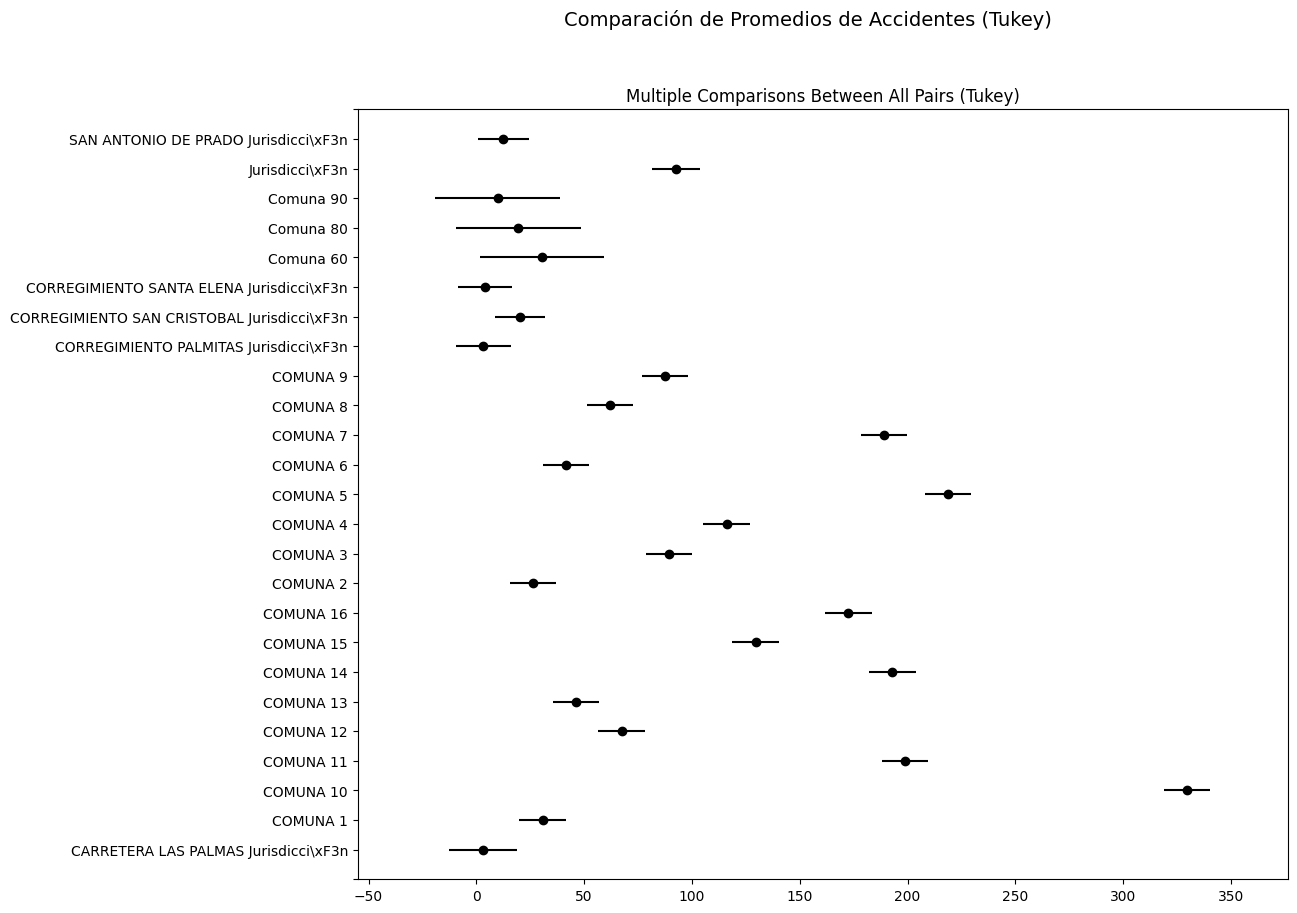

In [49]:
# Post-hoc Tukey HSD test
if p_valor_anova < 0.05:
    print("\nPrueba de diferencia de medias (Tukey HSD):")
    print("Planteamos las hipótesis para cada par de promedios:")
    print(" H0: mu_1 = mu_2 (Los promedios son iguales)")
    print(" H1: mu_1 != mu_2 (Los promedios son diferentes)\n")

    tukey = pairwise_tukeyhsd(endog=df_anova['CANTIDAD_ACCIDENTES'],
                              groups=df_anova['ZONA'],
                              alpha=0.05)
    print(tukey.summary())

    # Graficar
    fig = tukey.plot_simultaneous(figsize=(12, 10))
    fig.suptitle('Comparación de Promedios de Accidentes (Tukey)', fontsize=14)
    plt.show()

# **6. Validación de supuestos**

**6.1 No Autocorrelación = Residuos aleatorios=Residuos independientes**

**Planteamos las hipótesis**

 $$ H_{0}:\text{No autocorrelación}$$
 $$ H_{1}:\text{Autocorrelación}$$

 Si el valor p es menor a 0.05 se debe rechazar H0

=== 6.1 No Autocorrelación = Residuos aleatorios ===
Planteamos las hipótesis:
 H0: No autocorrelación (Los residuos son independientes)
 H1: Autocorrelación (Los residuos NO son independientes)
 Si el valor p es menor a 0.05 se debe rechazar H0

a) Independence of residuals: Durbin-Watson
Durbin-Watson statistic: 0.5398
 -> El valor está fuera del rango (1.5 - 2.5), lo que indica que NO existe independencia.

b) Prueba de rachas (runs test):
Z = -16.1187, p-valor = 0.0000
 -> Como 0.0000 < 0.05, se debe rechazar H0, lo que indica que existe AUTOCORRELACIÓN

c) Gráfico de residuos:


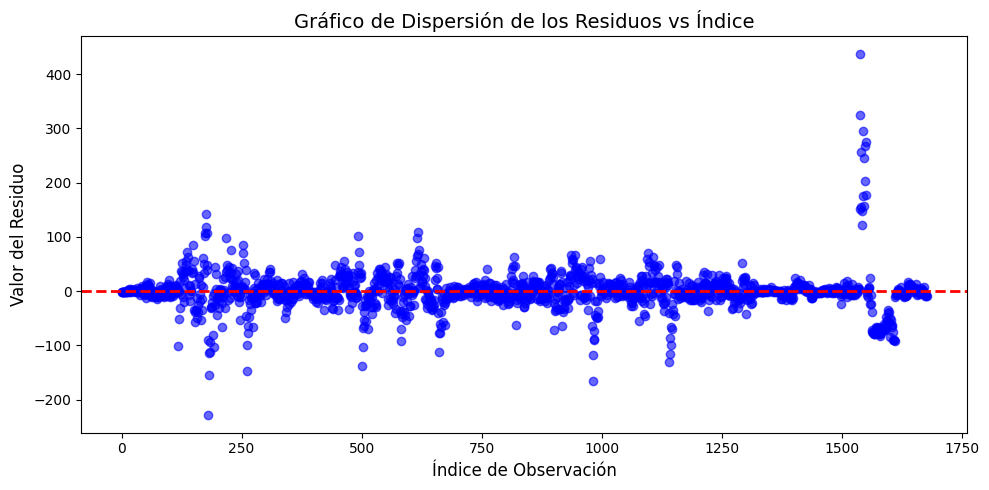

In [50]:
#El gráfico de residuos
# Calculamos los residuos del modelo una sola vez
residuos = modelo_anova.resid

print("="*60)
print("=== 6.1 No Autocorrelación = Residuos aleatorios ===")
print("Planteamos las hipótesis:")
print(" H0: No autocorrelación (Los residuos son independientes)")
print(" H1: Autocorrelación (Los residuos NO son independientes)")
print(" Si el valor p es menor a 0.05 se debe rechazar H0\n")

print("a) Independence of residuals: Durbin-Watson")
dw_stat = durbin_watson(residuos)
print(f"Durbin-Watson statistic: {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print(" -> El valor está entre 1.5 y 2.5, lo que indica que SÍ existe independencia en los residuos.")
else:
    print(" -> El valor está fuera del rango (1.5 - 2.5), lo que indica que NO existe independencia.")

print("\nb) Prueba de rachas (runs test):")
z_stat, p_value_runs = runstest_1samp(residuos)
print(f"Z = {z_stat:.4f}, p-valor = {p_value_runs:.4f}")
if p_value_runs < 0.05:
    print(f" -> Como {p_value_runs:.4f} < 0.05, se debe rechazar H0, lo que indica que existe AUTOCORRELACIÓN")
else:
    print(f" -> Como {p_value_runs:.4f} >= 0.05, no se rechaza H0, NO existe AUTOCORRELACIÓN")

print("\nc) Gráfico de residuos:")
plt.figure(figsize=(10, 5))
plt.scatter(range(len(residuos)), residuos, color='blue', alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title("Gráfico de Dispersión de los Residuos vs Índice", fontsize=14)
plt.xlabel("Índice de Observación", fontsize=12)
plt.ylabel("Valor del Residuo", fontsize=12)
plt.tight_layout()
plt.show()

**6.2 Homoscedasticidad de los residuales**

**Planteamos las hipótesis**

 $$ H_{0}:\text{Homoscedasticidad en los residuales}$$
 $$ H_{1}:\text{Heteroscedasticidad en los residuales}$$

 Si el valor p es menor a 0.05 se debe rechazar H0

In [51]:
# Homoscedasticity: Levene test
levene_stat, levene_p = levene(*[df_anova.loc[df_anova['ZONA'] == c, 'CANTIDAD_ACCIDENTES'] for c in df_anova['ZONA'].unique()])
print(f"Levene test statistic: {levene_stat}, p-value: {levene_p}")

if levene_p < 0.05:
    print(f"Como {levene_p:.4f} < 0.05, se debe rechazar H0, lo que indica que existe HETEROSCEDASTICIDAD en los residuos")
else:
    print(f"Como {levene_p:.4f} >= 0.05, no se rechaza H0, existe HOMOSCEDASTICIDAD en los residuos")


Levene test statistic: 21.38771414676165, p-value: 3.921146704043963e-80
Como 0.0000 < 0.05, se debe rechazar H0, lo que indica que existe HETEROSCEDASTICIDAD en los residuos


**6.3 Normalidad de los residuales**

**Planteamos las hipótesis**

 $$ H_{0}:\text{Los residuos provienen de una distribución Normal}$$
 $$ H_{1}:\text{Los residuos NO provienen de una distribución Normal}$$

 Si el valor p es menor a 0.05 se debe rechazar H0


In [52]:
# 3. Normality of residuals: KS test
# Calculate residuals
ks_resid_stat, ks_resid_p = kstest(residuos, 'norm', args=(residuos.mean(), residuos.std()))
print(f"KS test on residuals statistic: {ks_resid_stat}, p-value: {ks_resid_p}")

if ks_resid_p < 0.05:
    print(f"Como {ks_resid_p:.4f} < 0.05, se debe rechazar H0, lo que indica que NO existe NORMALIDAD en los residuos")
else:
    print(f"Como {ks_resid_p:.4f} >= 0.05, no se rechaza H0, existe NORMALIDAD en los residuos")

KS test on residuals statistic: 0.1680859003757244, p-value: 6.555820096932588e-42
Como 0.0000 < 0.05, se debe rechazar H0, lo que indica que NO existe NORMALIDAD en los residuos
